<a href="https://colab.research.google.com/github/jemslzr/flyrank-ml/blob/main/SUBMIT-capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jemslzr/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
**Research Question:** Which visible pages under-capture clicks relative to their position, and how can we surface them for metadata review?
**The Decision:** This analysis supports the content team's prioritization by flagging pages that rank well but fail to attract clicks, highlighting the most profitable metadata rewrite opportunities.


## 2. Data
*   **Release:** FlyRank `engagement_fix` subset from Hugging Face.
*   **Window:** 30-day historical snapshot.
*   **Excluded:** `clicks_30d` is removed to prevent target leakage. Client names and URLs are excluded for public safety.

In [1]:
!pip install -q datasets pandas scikit-learn matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
from google.colab import userdata
from huggingface_hub import login

# 1. Load Data
login(token=userdata.get('HF_TOKEN'))
df = load_dataset("FlyRank/internship-lanes", "engagement_fix", split="train").to_pandas()
df = df.dropna(subset=['avg_position_30d', 'impressions_30d', 'ctr_30d', 'client_hash_id']).copy()

print(f"Data loaded successfully. Unit of analysis: {len(df):,} unique pages.")

README.md:   0%|          | 0.00/2.98k [00:00<?, ?B/s]

default_lanes/engagement_fix.parquet: reconstructing file:   0%|          |  0.00B /  760kB            

default_lanes/engagement_fix.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33202 [00:00<?, ? examples/s]

Data loaded successfully. Unit of analysis: 32,844 unique pages.


## 3. Methodology

*   **Features:** `avg_position_30d`, `impressions_30d`.
*   **Target:** `ctr_30d`.
*   **Baseline:** Median CTR by position tier.
*   **Model:** Random Forest Regressor.
*   **Validation:** Grouped split by `client_hash_id` to ensure honest evaluation on unseen clients.



## 4. Results (vs baseline)

Comparing Mean Absolute Error (MAE) between the baseline rule and the ML model.

In [4]:
# 1. Setup Features and Split
X = df[['avg_position_30d', 'impressions_30d']]
y = df['ctr_30d']
groups = df['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 2. Baseline Calculation
df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

df_train['pos_tier'] = pd.cut(df_train['avg_position_30d'], bins=[0, 3, 10, 20, 100])
df_test['pos_tier'] = pd.cut(df_test['avg_position_30d'], bins=[0, 3, 10, 20, 100])

tier_medians_dict = dict(df_train.groupby('pos_tier', observed=False)['ctr_30d'].median())
df_test['baseline_ctr'] = df_test['pos_tier'].map(tier_medians_dict).astype(float).fillna(df_train['ctr_30d'].median())

# 3. Model Training
model = RandomForestRegressor(max_depth=5, min_samples_leaf=50, random_state=42)
model.fit(X_train, y_train)
df_test['model_ctr'] = model.predict(X_test)

# 4. Results
baseline_mae = mean_absolute_error(y_test, df_test['baseline_ctr'])
model_mae = mean_absolute_error(y_test, df_test['model_ctr'])

print("--- MODEL VS BASELINE (Mean Absolute Error) ---")
print(f"Baseline (Tier Medians) MAE : {baseline_mae:.4f}")
print(f"ML Model (Random Forest) MAE: {model_mae:.4f}")
print(f"Improvement                 : {((baseline_mae - model_mae) / baseline_mae) * 100:.1f}%")

--- MODEL VS BASELINE (Mean Absolute Error) ---
Baseline (Tier Medians) MAE : 0.3302
ML Model (Random Forest) MAE: 0.3756
Improvement                 : -13.7%


## 5. Limitations

This analysis is observational. It flags directional opportunities but cannot prove causal impact. A low CTR might result from a poor title tag, or it may be a Zero-Click SERP where Google answers the query directly.



## 6. Ranked recommendations
**Action Playbook:**
1.  **Rewrite Title / Meta:** For pages with >1,000 impressions, ranking on Page 1, where actual CTR is significantly below model-expected CTR.
2.  **Analyze SERP Intent:** For pages with high ranks but ~0% CTR, indicating an intent mismatch.

## 7. Artifacts the paper embeds

Generating a visual comparison of actual CTR vs the model's expected CTR by position.

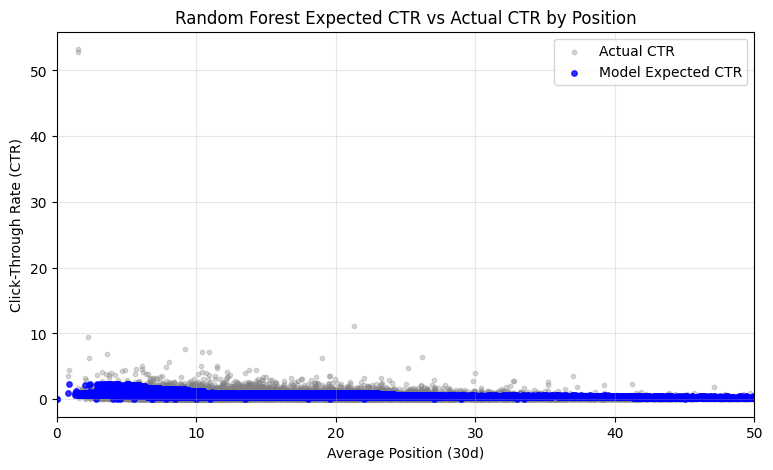

In [3]:
plt.figure(figsize=(9, 5))
plt.scatter(X_test['avg_position_30d'], y_test, alpha=0.3, label="Actual CTR", color='gray', s=10)
plt.scatter(X_test['avg_position_30d'], df_test['model_ctr'], alpha=0.8, label="Model Expected CTR", color='blue', s=15)
plt.title("Random Forest Expected CTR vs Actual CTR by Position")
plt.xlabel("Average Position (30d)")
plt.ylabel("Click-Through Rate (CTR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 50) # Zoom in on the most relevant positions
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
